## Visualize Tabulated Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [5]:
full_df = pd.read_excel("../data/twist/DOC-001414 Full Length UDI Adapter Sequences Reference Spreadsheet.xlsx",sheet_name="FL-UDI-Adapter-Plate-1",header=1).drop(columns="PLATE DESIGNATION")
full_df.head()

,INDEX,WELL,i7 INDEX REFERENCE FOR SAMPLE SHEET,i5 INDEX REFERENCE FOR SAMPLE SHEET (FORWARD ORIENTATION),i5 INDEX REFERENCE FOR SAMPLE SHEET (REVERSE ORIENTATION)
0,1,A01,CCATGGGACG,TAGACTCTGC,GCAGAGTCTA
1,2,B01,CAGACGTAAT,AGCTATTGTA,TACAATAGCT
2,3,C01,CTAGATCAAA,AACACCGGAC,GTCCGGTGTT
3,4,D01,TGAGGCACCG,TATCGGATTG,CAATCCGATA
4,5,E01,TATCAACGGT,TTGCACGCCG,CGGCGTGCAA


In [6]:
i5_fwd_map = full_df.set_index("i5 INDEX REFERENCE FOR SAMPLE SHEET (FORWARD ORIENTATION)")[['INDEX','WELL']].to_dict(orient="index")
i7_map = full_df.set_index("i7 INDEX REFERENCE FOR SAMPLE SHEET")[['INDEX','WELL']].to_dict(orient="index")

i5_fwd_map

{'TAGACTCTGC': {'INDEX': 1, 'WELL': 'A01'},
 'AGCTATTGTA': {'INDEX': 2, 'WELL': 'B01'},
 'AACACCGGAC': {'INDEX': 3, 'WELL': 'C01'},
 'TATCGGATTG': {'INDEX': 4, 'WELL': 'D01'},
 'TTGCACGCCG': {'INDEX': 5, 'WELL': 'E01'},
 'TGTCAAGTGG': {'INDEX': 6, 'WELL': 'F01'},
 'GCTCGTGTTC': {'INDEX': 7, 'WELL': 'G01'},
 'AATTCGCCAG': {'INDEX': 8, 'WELL': 'H01'},
 'TTCCTTCGCG': {'INDEX': 9, 'WELL': 'A02'},
 'CTTTATCTGG': {'INDEX': 10, 'WELL': 'B02'},
 'TTGAGCGGAA': {'INDEX': 11, 'WELL': 'C02'},
 'TAATCATACT': {'INDEX': 12, 'WELL': 'D02'},
 'CCAGTAGTTT': {'INDEX': 13, 'WELL': 'E02'},
 'CGGTATACTG': {'INDEX': 14, 'WELL': 'F02'},
 'GAATTGTTCT': {'INDEX': 15, 'WELL': 'G02'},
 'TTCCACACTA': {'INDEX': 16, 'WELL': 'H02'},
 'CACATACACG': {'INDEX': 17, 'WELL': 'A03'},
 'TCATGGTGTG': {'INDEX': 18, 'WELL': 'B03'},
 'TCCATGGTAG': {'INDEX': 19, 'WELL': 'C03'},
 'TTGTTTGGCG': {'INDEX': 20, 'WELL': 'D03'},
 'AGGTTCATTA': {'INDEX': 21, 'WELL': 'E03'},
 'TGCAGAGGTT': {'INDEX': 22, 'WELL': 'F03'},
 'CACAACTCTG': {'IN

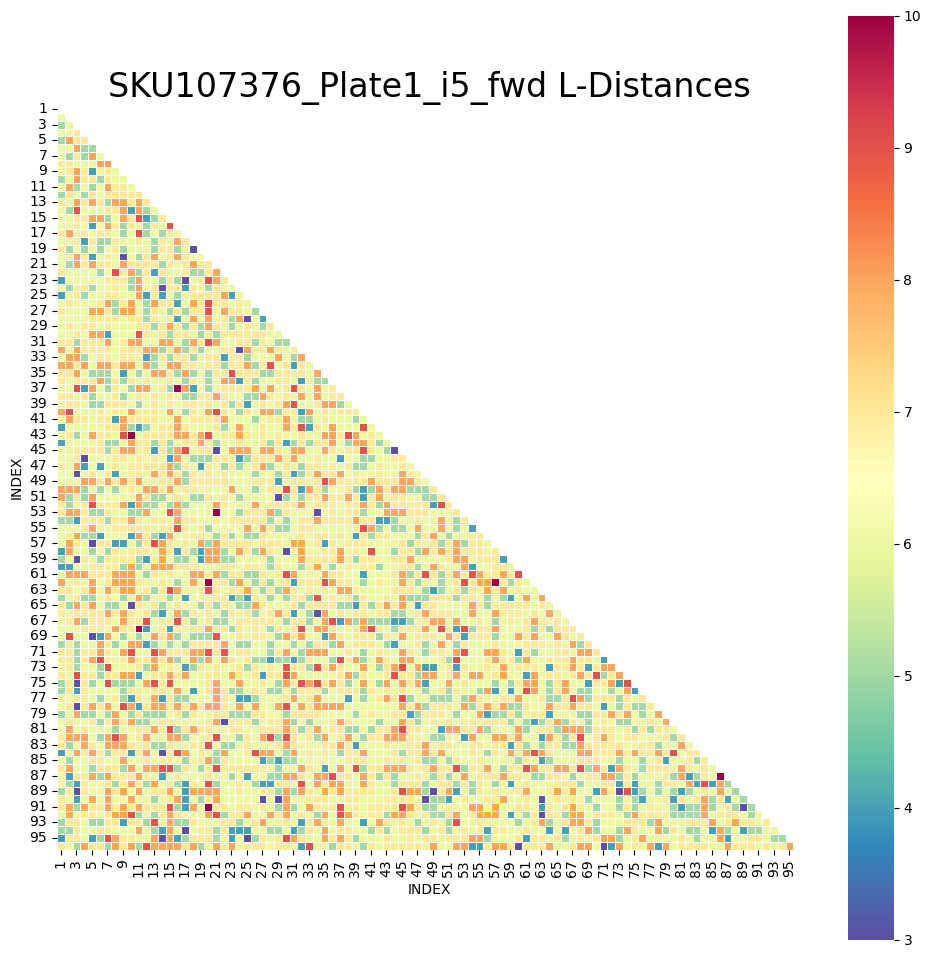

In [18]:
data_path = '../data/twist/SKU107376_Plate1_i5_fwd.barcodes.matrix.tsv'
df = pd.read_csv(data_path,delimiter='\t',header=0)

df = df.set_index(["Barcode"])
df.index = df.index.map(lambda x: i5_fwd_map[x]['INDEX']).rename("INDEX")
df.columns = df.columns.map(lambda x: i5_fwd_map[x]['INDEX']).rename("INDEX")

df = df.sort_index()[range(1,len(df)+1)]

mask = np.triu(np.ones_like(df.to_numpy(), dtype=bool))

plt.figure(figsize=(12,12))
sns.heatmap(df, mask = mask, square=True,cmap="Spectral_r",lw=.5,linecolor='w',)
plt.title("SKU107376_Plate1_i5_fwd L-Distances",fontsize=24)
plt.show()


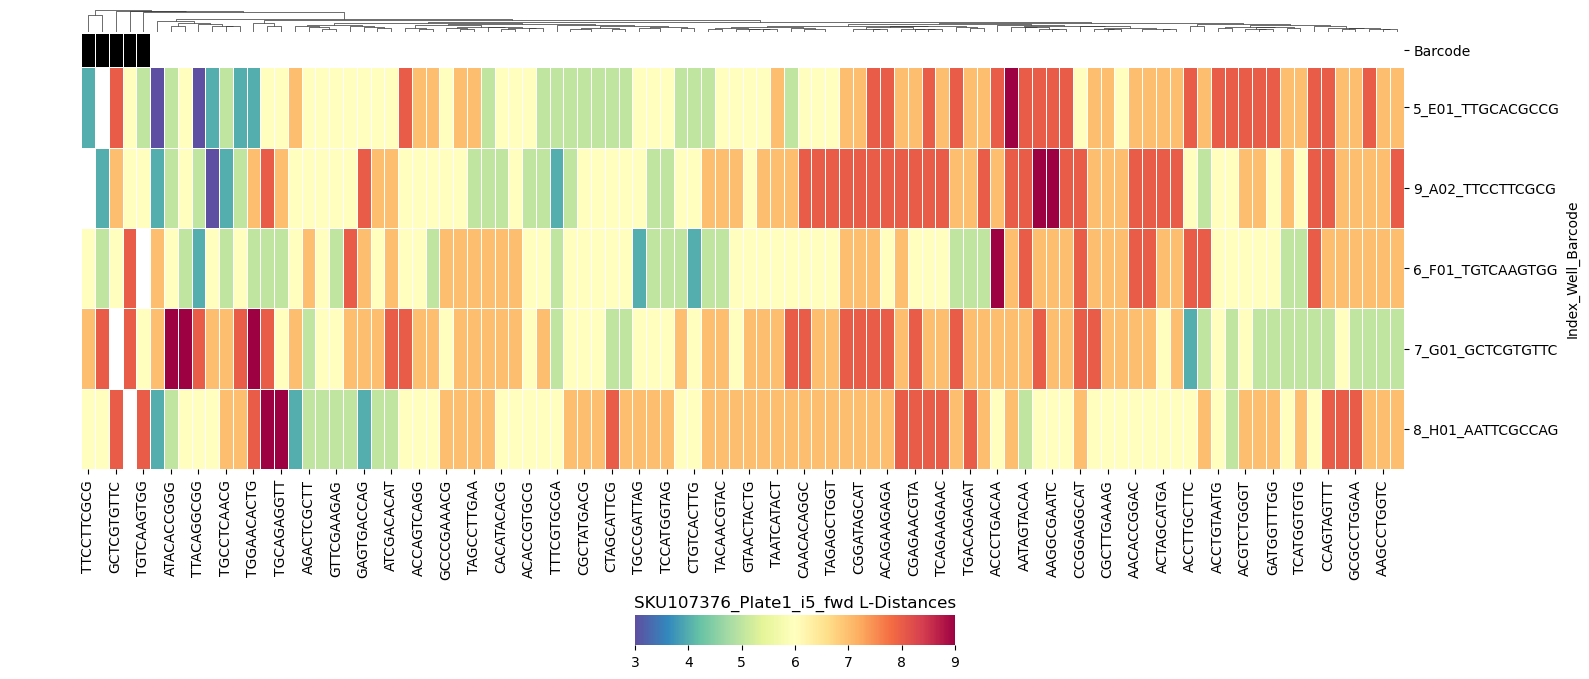

In [123]:
data_path = '../data/twist/SKU107376_Plate1_i5_fwd.barcodes.matrix.tsv'
df = pd.read_csv(data_path,delimiter='\t',header=0)


df['Index'] = df['Barcode'].map(lambda x: i5_fwd_map[x]['INDEX'])
df['Well'] = df['Barcode'].map(lambda x: i5_fwd_map[x]['WELL'])
df['Index_Well_Barcode']=df[["Index","Well","Barcode"]].astype(str).apply(lambda x: '_'.join(x), axis=1)


df_tmp = df.where(df['Index'].between(5,9)).dropna()
df_tmp = df_tmp.set_index(['Index_Well_Barcode'])


# df_tmp
# for (idx,well,bc), row in df_tmp.iterrows():
#     print("WELL TESTED: ",idx,well,bc)
#     print(row.sort_values(ascending=True)[0:5])
#     print()

mask = df_tmp.drop(columns =  ["Index","Well","Barcode"]) == 0

col_colors = df['Barcode'].astype(str).apply(lambda x: 'k' if x in df_tmp['Barcode'].astype(str).tolist() else 'w')
col_colors.index = df['Barcode']

f = sns.clustermap(df_tmp.drop(columns = ["Index","Well","Barcode"]),
                   colors_ratio=0.075, col_colors=col_colors, 
                   figsize=(16,6),
                   mask = mask,
                   square=False,
                   cmap="Spectral_r",
                   lw=.5,linecolor='w',
                   dendrogram_ratio = 0.05,
                   row_cluster=False,
                   cbar_pos=(.4, -.085, 0.2, .05), cbar_kws=dict(orientation='horizontal'))
plt.title("SKU107376_Plate1_i5_fwd L-Distances")
f.ax_heatmap.invert_yaxis()
plt.show()

WELL TESTED:  5 E01 TATCAACGGT
Index  Well  Barcode   
5      E01   TATCAACGGT    0
32     H04   GACCGACGGT    3
54     F07   ATAAACGGAT    3
36     D05   TTAAACGTTT    4
68     D09   AGTGAACGCT    4
Name: (5, E01, TATCAACGGT), dtype: int64

WELL TESTED:  6 F01 TAACTCTTCG
Index  Well  Barcode   
6      F01   TAACTCTTCG    0
83     C11   TCACTCTCGT    3
21     E03   TACACATCTG    4
60     D08   ATCTCTAACG    4
90     B12   CACTCCTCCG    4
Name: (6, F01, TAACTCTTCG), dtype: int64

WELL TESTED:  7 G01 AGATGAGCCA
Index  Well  Barcode   
7      G01   AGATGAGCCA    0
45     E06   CAGAGAGCAG    4
75     C10   CGTGAGTCAC    4
68     D09   AGTGAACGCT    4
1      A01   CCATGGGACG    5
Name: (7, G01, AGATGAGCCA), dtype: int64

WELL TESTED:  8 H01 TTGGAGATGT
Index  Well  Barcode   
8      H01   TTGGAGATGT    0
15     G02   CTGGACCTAT    4
37     E05   TTGGGAAATC    4
25     A04   CGGGAAGATG    4
24     H03   TGAGAGATCG    4
Name: (8, H01, TTGGAGATGT), dtype: int64

WELL TESTED:  9 A02 AGCCCGTGAT
I

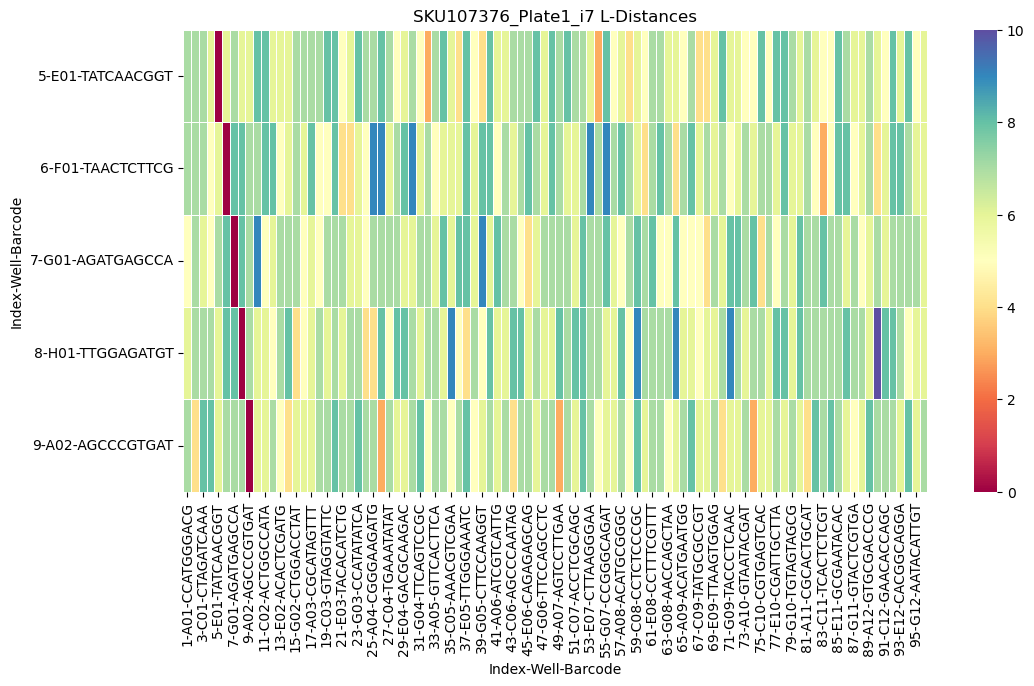

In [43]:
data_path = '../data/twist/SKU107376_Plate1_i7.barcodes.matrix.tsv'
df = pd.read_csv(data_path,delimiter='\t',header=0)

df['Index'] = df['Barcode'].map(lambda x: i7_map[x]['INDEX'])
df['Well'] = df['Barcode'].map(lambda x: i7_map[x]['WELL'])
df = df.set_index(["Index","Well","Barcode"])

# mask = np.triu(np.ones_like(df.to_numpy(), dtype=bool))

df_tmp = df.loc[range(5,10)]
df_tmp.columns = df_tmp.columns.map(lambda x: tuple(list(i7_map[x].values())+[x]))
df_tmp.columns.names = ["Index","Well","Barcode"]
df_tmp = df_tmp[sorted(df_tmp.columns.get_level_values(0))]

for (idx,well,bc), row in df_tmp.iterrows():
    print("WELL TESTED: ",idx,well,bc)
    print(row.sort_values(ascending=True)[0:5])
    print()

plt.figure(figsize=(12,6))
sns.heatmap(df_tmp, mask = None,square=False,cmap="Spectral",lw=.5)
plt.title("SKU107376_Plate1_i7 L-Distances")
plt.show()
